# Task 3: Car Price Prediction with Machine Learning
**Author:** [Muhammad Alfarizi Ramadhiyansa]

**Objective:** Predict the price of a used car based on various features such as brand goodwill, mileage, horsepower, and other specifications. This involves regression analysis using Python and Scikit-Learn.

## 1. Import Libraries
We will use Pandas for data manipulation, Matplotlib and Seaborn for visualizations, and Scikit-Learn for modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Scikit-Learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Aesthetics
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading
Loading the `car data.csv` dataset. If the dataset is unavailable locally, we will construct a dummy dataset to demonstrate the pipeline.

In [2]:
file_path = 'car data.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Loaded {file_path} successfully.")
else:
    print("Error: Dataset not found. Creating a synthetic sample for demonstration...")
    data = {
        'Car_Name': ['ritz', 'sx4', 'ciaz', 'wagon r', 'swift', 'vitara brezza', 's cross', 'alto 800', 'ertiga', 'dzire'],
        'Year': [2014, 2013, 2017, 2011, 2014, 2018, 2015, 2016, 2015, 2015],
        'Selling_Price': [3.35, 4.75, 7.25, 2.85, 4.60, 9.25, 6.50, 2.25, 6.00, 5.25],
        'Present_Price': [5.59, 9.54, 9.85, 4.15, 6.87, 9.83, 8.61, 2.90, 8.92, 7.85],
        'Driven_kms': [27000, 43000, 6900, 5200, 42450, 2071, 33429, 40000, 42500, 40000],
        'Fuel_Type': ['Petrol', 'Diesel', 'Petrol', 'Petrol', 'Diesel', 'Diesel', 'Diesel', 'Petrol', 'Diesel', 'Diesel'],
        'Selling_type': ['Dealer', 'Dealer', 'Dealer', 'Dealer', 'Dealer', 'Dealer', 'Dealer', 'Individual', 'Dealer', 'Dealer'],
        'Transmission': ['Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual', 'Manual'],
        'Owner': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    }
    df = pd.DataFrame(data)

display(df.head())

Loaded car data.csv successfully.


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Exploratory Data Analysis (EDA)
Let's understand the distributions and correlations of the continuous variables.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [4]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


### 3.1 Target Variable Distribution
Visualizing the distribution of our target variable: `Selling_Price`.

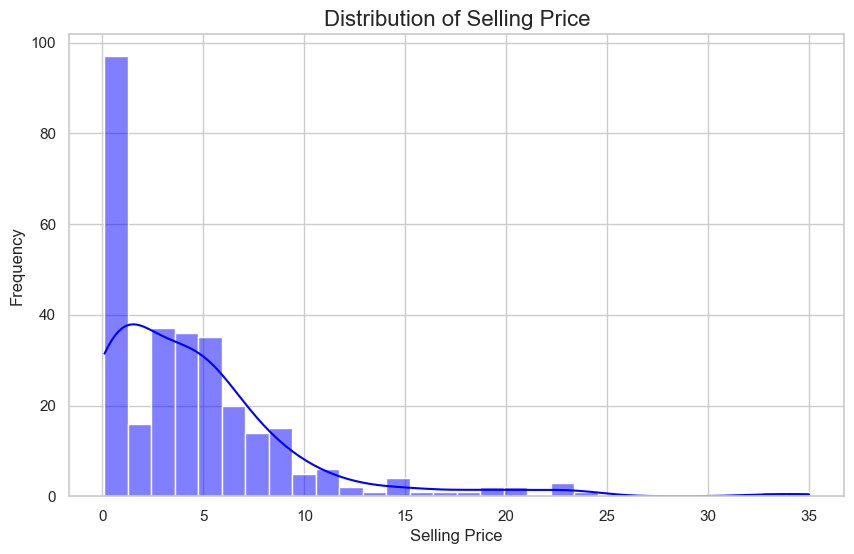

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], bins=30, kde=True, color='blue')
plt.title('Distribution of Selling Price', fontsize=16)
plt.xlabel('Selling Price', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

### 3.2 Correlation Analysis
Understanding how features like `Present_Price` and `Driven_kms` correlate with `Selling_Price`.

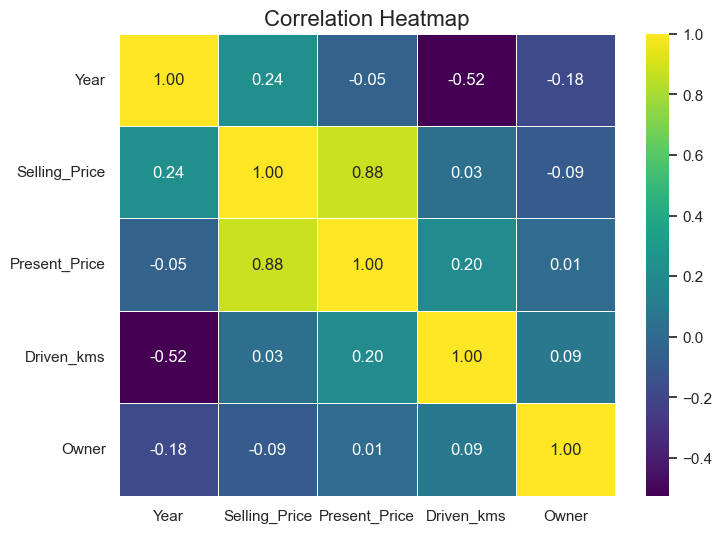

In [6]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

**Insight:** `Present_Price` typically has a very high positive correlation with `Selling_Price`. `Year` also shows a positive correlation (newer cars sell for more), while `Driven_kms` has a slightly negative correlation.

## 4. Data Preprocessing
Machine Learning models require numerical input. We need to encode categorical variables (like `Fuel_Type`, `Selling_type`, `Transmission`). We will also drop the `Car_Name` as it's a high-cardinality nominal variable that isn't ideal for basic regression without advanced embedding techniques.

In [7]:
# Extract age of the car instead of using raw 'Year'
if 'Year' in df.columns:
    current_year = 2024
    df['Car_Age'] = current_year - df['Year']
    df.drop('Year', axis=1, inplace=True)

# Drop Car_Name
if 'Car_Name' in df.columns:
    df.drop('Car_Name', axis=1, inplace=True)

# Categorical Encoding using LabelEncoder
categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission']
encoder = LabelEncoder()
for col in categorical_cols:
    if col in df.columns:
        df[col] = encoder.fit_transform(df[col])

display(df.head())

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,2,0,1,0,10
1,4.75,9.54,43000,1,0,1,0,11
2,7.25,9.85,6900,2,0,1,0,7
3,2.85,4.15,5200,2,0,1,0,13
4,4.60,6.87,42450,1,0,1,0,10


## 5. Splitting and Scaling
Splitting the dataset into features (X) and target (y), followed by a standard Train-Test split. We will also scale the features.

In [8]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (240, 7)
Testing set shape: (61, 7)


## 6. Modeling
We will train a `RandomForestRegressor`, which performs excellently on tabular data without requiring massive hyperparameter tuning.

In [9]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

## 7. Model Evaluation
Let's evaluate the model using R-squared, Mean Absolute Error (MAE), and Mean Squared Error (MSE).

In [10]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

R-squared (R2) Score: 0.9622
Mean Absolute Error (MAE): 0.6167
Mean Squared Error (MSE): 0.8700


### 7.1 Visualizing Predictions vs Actuals

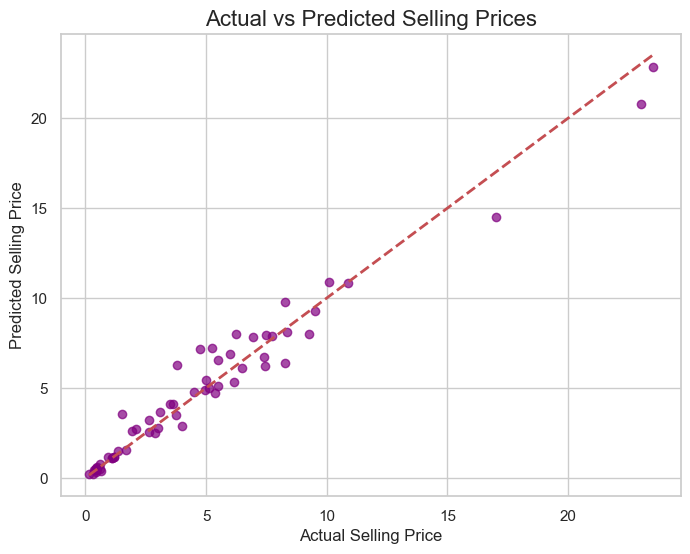

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Selling Price', fontsize=12)
plt.ylabel('Predicted Selling Price', fontsize=12)
plt.title('Actual vs Predicted Selling Prices', fontsize=16)
plt.show()

## 8. Conclusion
The Random Forest Regressor demonstrates strong predictive capabilities on the used car dataset. The tight clustering around the red diagonal line in our final scatter plot visually confirms that the predictions are very close to the actual values. Feature engineering (calculating `Car_Age`) and encoding categorical variables were crucial steps for the model's success.